# Statistical Baselines: Rolling Z-Score
In this notebook, we implement the rolling z-score approach on the three NAB datasets.
We compare the predicted anomalies (using a z-score threshold) against the actual known anomaly windows.
The data is sampled at 5-minute intervals, so a 24-hour window corresponds to 288 data points.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings('ignore')

# Load the anomaly labels
with open('../data/NAB/labels/combined_windows.json', 'r') as f:
    labels = json.load(f)

# Define window size for 24 hours (5-min intervals: 12 points/hour * 24 hours = 288)
WINDOW_SIZE = 288


## 1. Machine Temperature System Failure
This dataset represents temperature sensor data from an internal component of a large industrial machine. We apply the 24-hour rolling Z-score to detect anomalies.

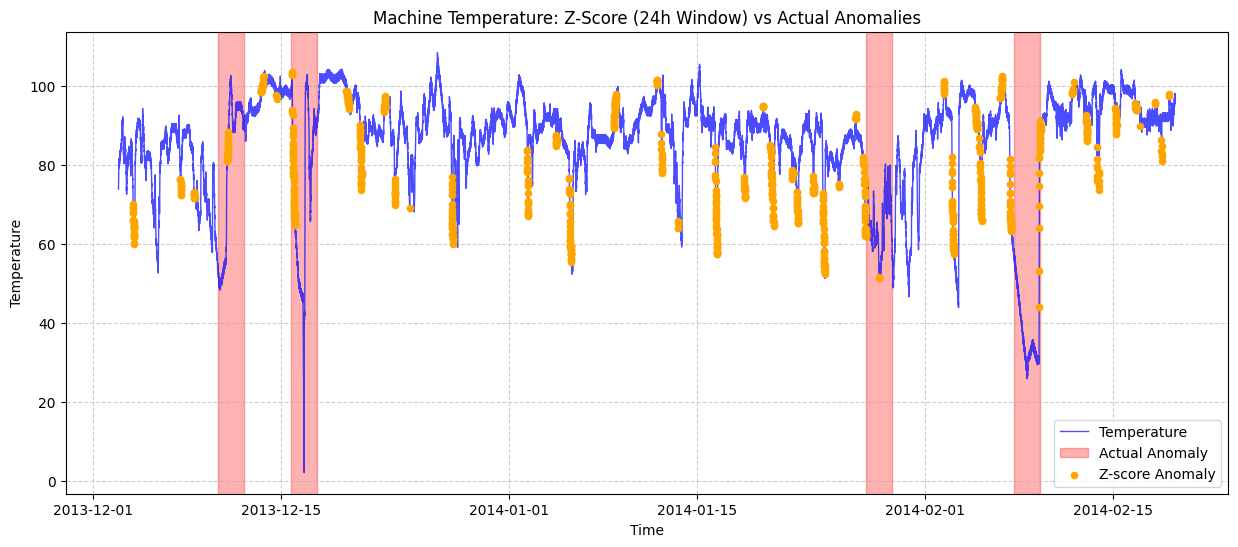

In [2]:
# 1. Machine Temperature System Failure
df1 = pd.read_csv('../data/NAB/data/realKnownCause/machine_temperature_system_failure.csv')
df1['timestamp'] = pd.to_datetime(df1['timestamp'])

# Rolling z-score
df1['rolling_mean'] = df1['value'].rolling(WINDOW_SIZE).mean()
df1['rolling_std'] = df1['value'].rolling(WINDOW_SIZE).std()
df1['z_score'] = (df1['value'] - df1['rolling_mean']) / df1['rolling_std']
df1['anomaly_zscore'] = (df1['z_score'].abs() > 3).astype(int)

# Extract the specific anomaly windows
file_key1 = 'realKnownCause/machine_temperature_system_failure.csv'
anomaly_windows1 = labels.get(file_key1, [])

plt.figure(figsize=(15, 6))
plt.plot(df1['timestamp'], df1['value'], color='blue', linewidth=1, label='Temperature', alpha=0.7)

# Highlight the actual anomaly windows in red
for i, window_val in enumerate(anomaly_windows1):
    start_time = pd.to_datetime(window_val[0])
    end_time = pd.to_datetime(window_val[1])
    plt.axvspan(start_time, end_time, color='red', alpha=0.3, label='Actual Anomaly' if i == 0 else "")

# Highlight Z-score predictions in orange
anomalies1 = df1[df1['anomaly_zscore'] == 1]
plt.scatter(anomalies1['timestamp'], anomalies1['value'], color='orange', s=20, label='Z-score Anomaly', zorder=5)

plt.title('Machine Temperature: Z-Score (24h Window) vs Actual Anomalies')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()


## 2. EC2 CPU Utilization
This dataset contains CPU utilization metrics from an AWS EC2 instance. The rolling Z-score will help identify unexpected spikes or drops in CPU load.

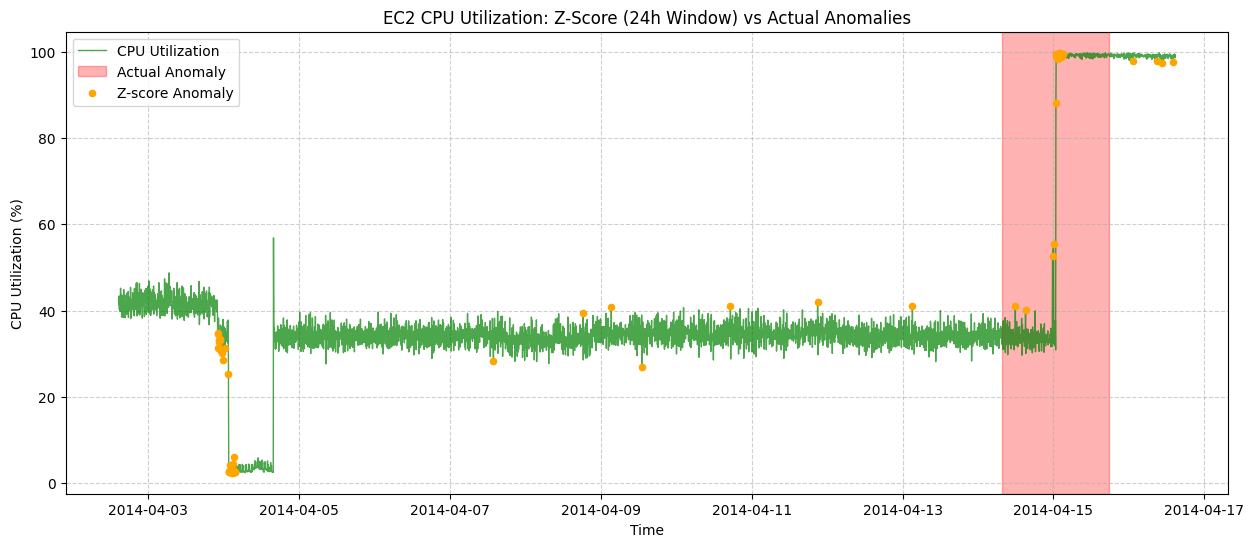

In [3]:
# 2. EC2 CPU Utilization
df2 = pd.read_csv('../data/NAB/data/realAWSCloudwatch/ec2_cpu_utilization_ac20cd.csv')
df2['timestamp'] = pd.to_datetime(df2['timestamp'])

# Rolling z-score
df2['rolling_mean'] = df2['value'].rolling(WINDOW_SIZE).mean()
df2['rolling_std'] = df2['value'].rolling(WINDOW_SIZE).std()
df2['z_score'] = (df2['value'] - df2['rolling_mean']) / df2['rolling_std']
df2['anomaly_zscore'] = (df2['z_score'].abs() > 3).astype(int)

# Extract the specific anomaly windows
file_key2 = 'realAWSCloudwatch/ec2_cpu_utilization_ac20cd.csv'
anomaly_windows2 = labels.get(file_key2, [])

plt.figure(figsize=(15, 6))
plt.plot(df2['timestamp'], df2['value'], color='green', linewidth=1, label='CPU Utilization', alpha=0.7)

# Highlight the actual anomaly windows in red
for i, window_val in enumerate(anomaly_windows2):
    start_time = pd.to_datetime(window_val[0])
    end_time = pd.to_datetime(window_val[1])
    plt.axvspan(start_time, end_time, color='red', alpha=0.3, label='Actual Anomaly' if i == 0 else "")

# Highlight Z-score predictions in orange
anomalies2 = df2[df2['anomaly_zscore'] == 1]
plt.scatter(anomalies2['timestamp'], anomalies2['value'], color='orange', s=20, label='Z-score Anomaly', zorder=5)

plt.title('EC2 CPU Utilization: Z-Score (24h Window) vs Actual Anomalies')
plt.xlabel('Time')
plt.ylabel('CPU Utilization (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()


## 3. Traffic Speed
This dataset captures traffic speed metrics. We use the rolling Z-score to find anomalous traffic patterns, such as sudden congestion or unusually high speeds.

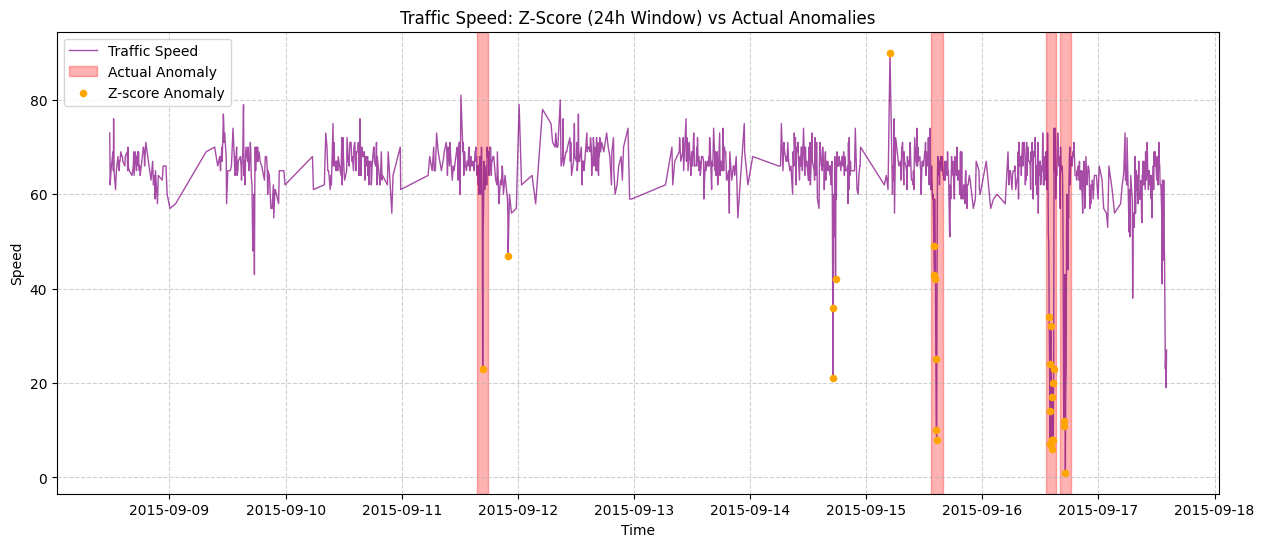

In [4]:
# 3. Traffic Speed
df3 = pd.read_csv('../data/NAB/data/realTraffic/speed_7578.csv')
df3['timestamp'] = pd.to_datetime(df3['timestamp'])

# Rolling z-score
df3['rolling_mean'] = df3['value'].rolling(WINDOW_SIZE).mean()
df3['rolling_std'] = df3['value'].rolling(WINDOW_SIZE).std()
df3['z_score'] = (df3['value'] - df3['rolling_mean']) / df3['rolling_std']
df3['anomaly_zscore'] = (df3['z_score'].abs() > 3).astype(int)

# Extract the specific anomaly windows
file_key3 = 'realTraffic/speed_7578.csv'
anomaly_windows3 = labels.get(file_key3, [])

plt.figure(figsize=(15, 6))
plt.plot(df3['timestamp'], df3['value'], color='purple', linewidth=1, label='Traffic Speed', alpha=0.7)

# Highlight the actual anomaly windows in red
for i, window_val in enumerate(anomaly_windows3):
    start_time = pd.to_datetime(window_val[0])
    end_time = pd.to_datetime(window_val[1])
    plt.axvspan(start_time, end_time, color='red', alpha=0.3, label='Actual Anomaly' if i == 0 else "")

# Highlight Z-score predictions in orange
anomalies3 = df3[df3['anomaly_zscore'] == 1]
plt.scatter(anomalies3['timestamp'], anomalies3['value'], color='orange', s=20, label='Z-score Anomaly', zorder=5)

plt.title('Traffic Speed: Z-Score (24h Window) vs Actual Anomalies')
plt.xlabel('Time')
plt.ylabel('Speed')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()
